# Notebook 4: Deep Learning Models
## 1D-CNN (Primary) and BiLSTM (Secondary)

**Models:**
1. **1D-CNN** (primary) — learns local nucleotide motifs via sliding convolutional filters
2. **BiLSTM** (secondary) — captures long-range sequential dependencies

### Why 1D-CNN for DNA sequences?
A 1D convolutional filter sliding across a one-hot encoded DNA sequence is **functionally equivalent to a position weight matrix (PWM)** — the gold standard for motif detection in computational biology. The key advantage of the CNN is that it learns these motifs **automatically from data**, without requiring expert curation.

Each successive convolutional layer captures increasingly complex patterns:
- Layer 1 (kernel=7): detects 7-mer motifs (e.g., restriction sites, codon patterns)
- Layer 2 (kernel=5): combines motifs into larger regulatory elements
- Layer 3-4 (kernel=3): captures high-level genomic signatures specific to each subtype

### Why also BiLSTM?
While CNNs excel at local pattern detection, LSTMs can model **long-range dependencies** — e.g., covariation between distant positions in the pol gene. Comparing the two reveals whether subtype-specific signals are primarily local (CNN wins) or distributed (BiLSTM wins).

---

## Import Libraries

In [1]:
import os, sys, pickle, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

## Workspace & Environment Setup
Mounts Google Drive to access persistent project directories and configures the compute device.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final'
processed_data = os.path.join(projectdir, 'data', 'processed')
models_dir = os.path.join(projectdir, 'models')
reports = os.path.join(projectdir, 'reports', 'figures')
os.makedirs(models_dir, exist_ok=True)
os.makedirs(reports, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


## Set global random seed for reproducibility


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f'Random seed set to {SEED} for reproducibility.')

Random seed set to 42 for reproducibility.


## Data Loading
Loads the preprocessed datasets or data objects from disk for downstream tasks.

In [4]:
# Load preprocessed data
with open(os.path.join(processed_data, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
label_to_idx = data['label_to_idx']
idx_to_label = data['idx_to_label']
num_classes = data['num_classes']
MAX_LENGTH = data['max_length']

print(f'Classes: {list(label_to_idx.keys())} ({num_classes} classes)')
print(f'Max length: {MAX_LENGTH}')
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Classes: ['A', 'B', 'C', 'D'] (4 classes)
Max length: None
Train: 3896 | Val: 833 | Test: 835


## Create Data Loaders

In [5]:
import sys
sys.path.append(os.path.join(projectdir, 'src'))
import pip
try:
    import Bio
except ImportError:
    %pip install biopython -q
    import Bio
from data_loader import HIVSequenceDataset, collate_onehot, collate_label


BATCH_SIZE = 32

def make_loaders(encoding='onehot'):
    # Create datasets
    train_ds = HIVSequenceDataset(X_train, y_train, MAX_LENGTH, encoding)
    val_ds = HIVSequenceDataset(X_val, y_val, MAX_LENGTH, encoding)
    test_ds = HIVSequenceDataset(X_test, y_test, MAX_LENGTH, encoding)

    # Select collate function for dynamic padding
    collate_fn = collate_onehot if encoding == 'onehot' else collate_label

    # Create loaders
    # Shuffle training data to prevent cyclical batching biases
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=collate_fn)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True, collate_fn=collate_fn)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=collate_fn)

    return train_dl, val_dl, test_dl



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.9 MB/s eta 0:00:00


## Training Utilities

Same training loop as Notebook 03, reused here for consistency.

In [6]:
import copy
from torch.utils.tensorboard import SummaryWriter

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in tqdm(loader, desc='  Train', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
    return total_loss/total, correct/total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='  Val', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return total_loss/total, correct/total

# Initiate full training pipeline with early stopping
def train_model(model, train_dl, val_dl, model_name, epochs=50, lr=1e-3, patience=10):
    try:
        weights = torch.load(os.path.join(projectdir, 'data', 'processed', 'class_weights.pt')).to(device)
        import sys
        src_path = os.path.join(projectdir, 'src')
        if src_path not in sys.path:
            sys.path.append(src_path)
        from train import FocalLoss
        # Focal Loss focuses on hard-to-predict minority classes
        criterion = FocalLoss(alpha=weights, gamma=2.0)
        print('Loaded balanced class weights and initialized FocalLoss.')
    except FileNotFoundError:
        import sys
        src_path = os.path.join(projectdir, 'src')
        if src_path not in sys.path:
            sys.path.append(src_path)
        from train import FocalLoss
        # Focal Loss focuses on hard-to-predict minority classes
        criterion = FocalLoss(gamma=2.0)
        print('Class weights not found, using standard FocalLoss.')
    # Initialize AdamW optimizer with weight decay for regularization
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    # Set up TensorBoard writer
    log_dir = os.path.join(projectdir, 'logs', model_name)
    writer = SummaryWriter(log_dir=log_dir)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    print(f'\n{"="*50}\nTraining: {model_name}\n{"="*50}')
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {total_params:,}')
    print(f'TensorBoard logging to: {log_dir}')

    for epoch in range(epochs):
        lr_now = optimizer.param_groups[0]['lr']
        t_loss, t_acc = train_epoch(model, train_dl, criterion, optimizer)
        v_loss, v_acc = eval_epoch(model, val_dl, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(lr_now)

        # Log to TensorBoard
        writer.add_scalars('Loss', {'train': t_loss, 'val': v_loss}, epoch)
        writer.add_scalars('Accuracy', {'train': t_acc, 'val': v_acc}, epoch)
        writer.add_scalar('Learning Rate', lr_now, epoch)

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'TL: {t_loss:.4f} TA: {t_acc:.4f} | '
              f'VL: {v_loss:.4f} VA: {v_acc:.4f} | LR: {lr_now:.6f}')

        if v_loss < best_val_loss - 0.001:
            best_val_loss = v_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    writer.close()

    if best_state:
        model.load_state_dict(best_state)
    torch.save({'state_dict': model.state_dict(), 'history': history},
               os.path.join(models_dir, f'{model_name}_best.pth'))
    print(f'Best val loss: {best_val_loss:.4f}')
    return history

print('Training utilities ready with TensorBoard Tracking.')


Training utilities ready with TensorBoard Tracking.


## Experiment tracking

In [7]:
%load_ext tensorboard
import os
# Ensure logs directory exists
os.makedirs(os.path.join(projectdir, 'logs'), exist_ok=True)


---
## Model 1: 1D-CNN (Primary Deep Learning Model)

### Architecture
```
Input (5 × 3000) → Conv1d(7) → BN → ReLU → MaxPool(4) → Dropout
                  → Conv1d(5) → BN → ReLU → MaxPool(4) → Dropout
                  → Conv1d(3) → BN → ReLU → MaxPool(4) → Dropout
                  → Conv1d(3) → BN → ReLU → GlobalAvgPool
                  → FC(256→128) → ReLU → Dropout → FC(128→4)
```

### Why this architecture?
- **4 conv blocks** progressively increase the receptive field from 7bp to hundreds of bp
- **MaxPool(4)** reduces the sequence length by 4× at each stage: 3000 → 750 → 187 → 46
- **AdaptiveAvgPool1d(1)** produces a single 256-dim feature vector regardless of input length
- **BatchNorm** stabilizes training; **Dropout(0.3)** prevents overfitting

In [8]:
class HIV_CNN(nn.Module):
    """1D-CNN for HIV pol gene subtype classification."""

    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(1), nn.Dropout(dropout),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(1), nn.Dropout(dropout),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(1), nn.Dropout(dropout),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

# Train CNN
MAX_LENGTH = 3000 # Set MAX_LENGTH explicitly for CNN input
train_dl, val_dl, test_dl = make_loaders('onehot')
cnn_model = HIV_CNN(num_classes).to(device)
cnn_history = train_model(cnn_model, train_dl, val_dl, 'HIV_CNN',
                          epochs=20, lr=1e-3, patience=5)

Loaded balanced class weights and initialized FocalLoss.

Training: HIV_CNN
Parameters: 94,436
TensorBoard logging to: /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/logs/HIV_CNN


Epoch  1/20 | TL: 0.8301 TA: 0.3237 | VL: 0.7745 VA: 0.5222 | LR: 0.001000


Epoch  2/20 | TL: 0.7871 TA: 0.4081 | VL: 0.9425 VA: 0.5222 | LR: 0.000994


Epoch  3/20 | TL: 0.6803 TA: 0.6884 | VL: 2.2840 VA: 0.5222 | LR: 0.000976


Epoch  4/20 | TL: 0.5718 TA: 0.7854 | VL: 3.5915 VA: 0.5222 | LR: 0.000946


Epoch  5/20 | TL: 0.4783 TA: 0.7962 | VL: 3.8898 VA: 0.5222 | LR: 0.000905


Epoch  6/20 | TL: 0.4399 TA: 0.8042 | VL: 5.9841 VA: 0.5222 | LR: 0.000854
Early stopping at epoch 6
Best val loss: 0.7745


## 1D-CNN — Test Set Evaluation

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
class_names = [idx_to_label[i] for i in range(num_classes)]
def get_predictions(model, dl):
    model.eval()
    all_preds, all_labels, all_proba = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dl, desc='Predicting', leave=False):
            outputs = model(inputs.to(device))
            proba = torch.softmax(outputs, dim=1)
            _, pred = torch.max(outputs, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_proba.extend(proba.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_proba)

cnn_yt, cnn_yp, cnn_yprob = get_predictions(cnn_model, test_dl)
cnn_acc = accuracy_score(cnn_yt, cnn_yp)
print('=== 1D-CNN — Test Set Results ===')
print(classification_report(cnn_yt, cnn_yp, target_names=class_names, digits=4))

=== 1D-CNN — Test Set Results ===
              precision    recall  f1-score   support

           A     0.0000    0.0000    0.0000        42
           B     0.5222    1.0000    0.6861       436
           C     0.0000    0.0000    0.0000       346
           D     0.0000    0.0000    0.0000        11

    accuracy                         0.5222       835
   macro avg     0.1305    0.2500    0.1715       835
weighted avg     0.2726    0.5222    0.3582       835



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion matrix

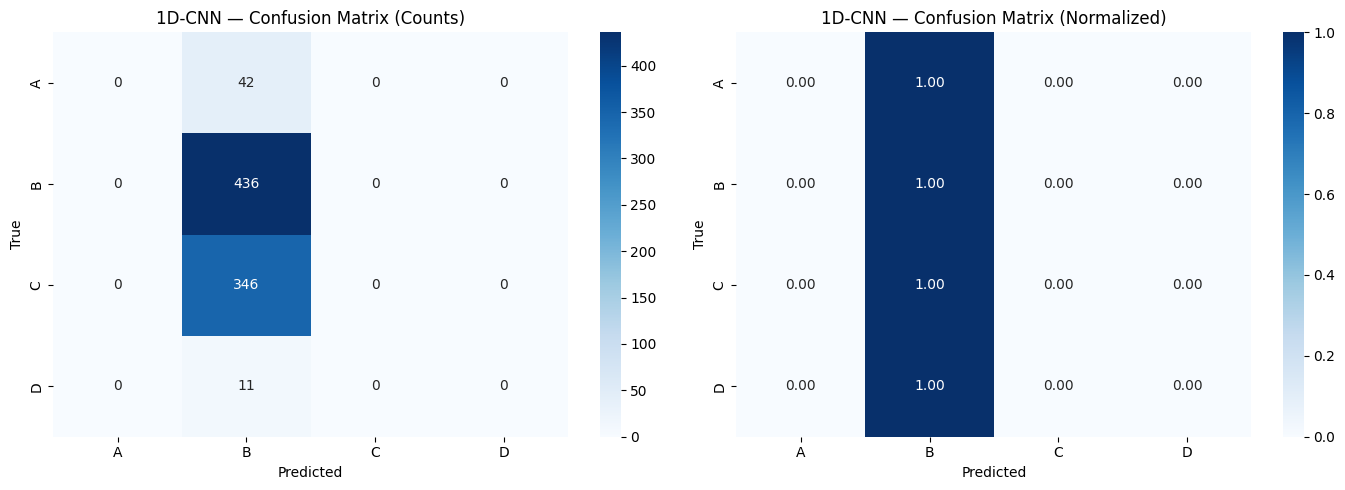

In [10]:
import seaborn as sns
    # Compute confusion matrix to analyze misclassifications
cm = confusion_matrix(cnn_yt, cnn_yp)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('1D-CNN — Confusion Matrix (Counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('1D-CNN — Confusion Matrix (Normalized)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Model 2: BiLSTM (Secondary Experiment)

### Architecture
```
Input (seq_len) → Embedding(6→128) → Dropout
                → BiLSTM(128→256×2, 2 layers)
                → Concat forward+backward hidden states
                → FC(512→128) → ReLU → Dropout → FC(128→4)
```

### Why include BiLSTM?
- LSTMs process the sequence **one nucleotide at a time**, maintaining a hidden state that captures context from all previous positions
- **Bidirectional** means it reads 5'→3' AND 3'→5', capturing dependencies in both directions
- If BiLSTM outperforms CNN, it suggests **long-range covariation** between distant genome positions is important for subtype classification
- If CNN wins, it suggests **local motifs** are the primary discriminative features

In [11]:
class HIV_BiLSTM(nn.Module):
    """Bidirectional LSTM for HIV pol gene subtype classification."""

    def __init__(self, num_classes, vocab=5, embed=128, hidden=256, layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab, embed, padding_idx=5)
        self.lstm = nn.LSTM(embed, hidden, layers, batch_first=True,
                           bidirectional=True, dropout=dropout if layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        out = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(out))

# Train BiLSTM
train_dl_lbl, val_dl_lbl, test_dl_lbl = make_loaders('label')
lstm_model = HIV_BiLSTM(num_classes, vocab=6).to(device)
lstm_history = train_model(lstm_model, train_dl_lbl, val_dl_lbl, 'HIV_BiLSTM',
                           epochs=30, lr=5e-4, patience=5)

Loaded balanced class weights and initialized FocalLoss.

Training: HIV_BiLSTM
Parameters: 2,434,436
TensorBoard logging to: /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/logs/HIV_BiLSTM


Epoch  1/30 | TL: 0.6472 TA: 0.5398 | VL: 0.5117 VA: 0.7467 | LR: 0.000500


Epoch  2/30 | TL: 0.4460 TA: 0.7721 | VL: 0.4190 VA: 0.7563 | LR: 0.000499


Epoch  3/30 | TL: 0.3288 TA: 0.7939 | VL: 0.3641 VA: 0.8211 | LR: 0.000495


Epoch  4/30 | TL: 0.3207 TA: 0.8234 | VL: 0.4139 VA: 0.8655 | LR: 0.000488


...

Epoch 18/30 | TL: 0.0667 TA: 0.9748 | VL: 0.2217 VA: 0.9808 | LR: 0.000199


Epoch 19/30 | TL: 0.0821 TA: 0.9792 | VL: 0.2032 VA: 0.9796 | LR: 0.000173


Epoch 20/30 | TL: 0.0746 TA: 0.9784 | VL: 0.2108 VA: 0.9808 | LR: 0.000149


Epoch 21/30 | TL: 0.0812 TA: 0.9802 | VL: 0.2006 VA: 0.9664 | LR: 0.000126


Epoch 22/30 | TL: 0.0632 TA: 0.9754 | VL: 0.2235 VA: 0.9724 | LR: 0.000104
Early stopping at epoch 22
Best val loss: 0.1936


## BiLSTM — Test Set Evaluation

In [12]:
lstm_yt, lstm_yp, lstm_yprob = get_predictions(lstm_model, test_dl_lbl)
lstm_acc = accuracy_score(lstm_yt, lstm_yp)
print('=== BiLSTM — Test Set Results ===')
print(classification_report(lstm_yt, lstm_yp, target_names=class_names, digits=4))

=== BiLSTM — Test Set Results ===
              precision    recall  f1-score   support

           A     0.5775    0.9762    0.7257        42
           B     0.9902    0.9266    0.9573       436
           C     0.9884    0.9884    0.9884       346
           D     0.8000    0.7273    0.7619        11

    accuracy                         0.9521       835
   macro avg     0.8390    0.9046    0.8583       835
weighted avg     0.9662    0.9521    0.9560       835



## Model Evaluation
Generates predictions on the test set and calculates key metrics including precision, recall, and the confusion matrix.

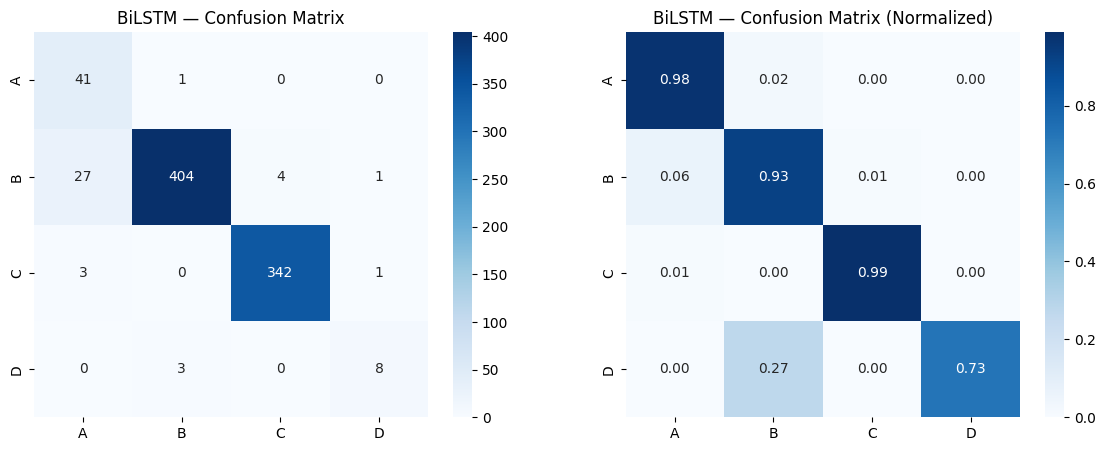

In [13]:
    # Compute confusion matrix to analyze misclassifications
cm_lstm = confusion_matrix(lstm_yt, lstm_yp)
cm_lstm_norm = cm_lstm.astype('float') / cm_lstm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('BiLSTM — Confusion Matrix')
sns.heatmap(cm_lstm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('BiLSTM — Confusion Matrix (Normalized)')
plt.show()

## Compare Training Curves

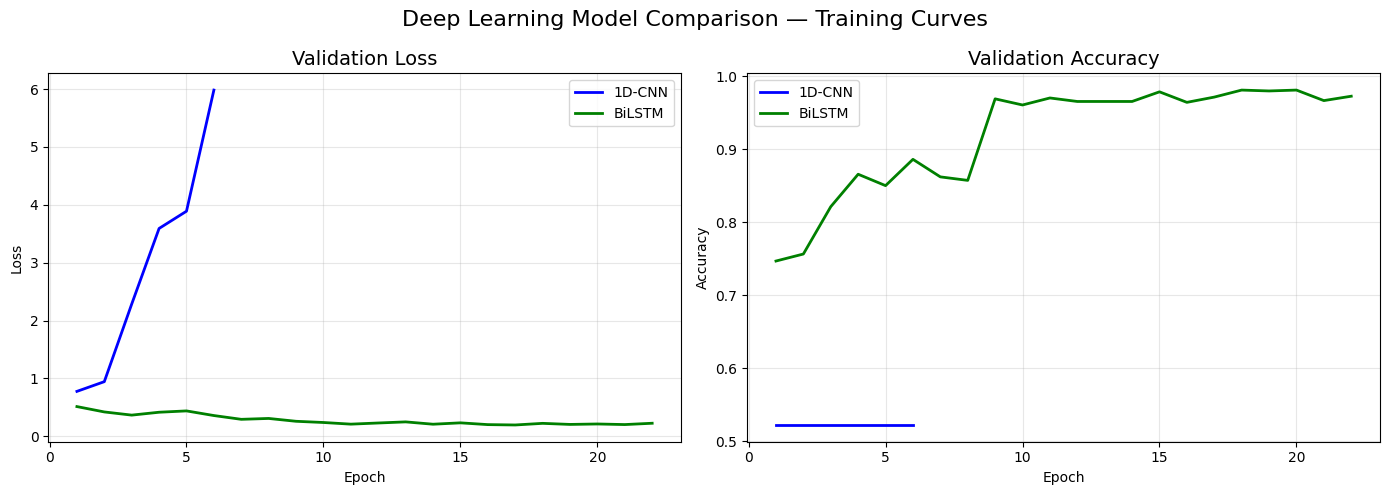

In [14]:
# Plot training curves for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist, color in [
    ('1D-CNN', cnn_history, 'blue'),
    ('BiLSTM', lstm_history, 'green'),
]:
    epochs = range(1, len(hist['val_loss'])+1)
    axes[0].plot(epochs, hist['val_loss'], color=color, label=name, lw=2)
    axes[1].plot(epochs, hist['val_acc'], color=color, label=name, lw=2)

axes[0].set_title('Validation Loss', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Deep Learning Model Comparison — Training Curves', fontsize=16)
plt.tight_layout()
plt.savefig(f'{reports}/model_comparison_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Code Execution Block
Executes sequential pipeline operations.

In [15]:
# Save all histories
all_histories = {
    'cnn': cnn_history,
    'bilstm': lstm_history,
}
with open(os.path.join(processed_data, 'training_histories.pkl'), 'wb') as f:
    pickle.dump(all_histories, f)

print('Both models trained and saved!')
print('--- Ready for Notebook 05: Evaluation & Analysis ---')

Both models trained and saved!
--- Ready for Notebook 05: Evaluation & Analysis ---
